## **1. Importer StatsForecast et des modèles**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

## **2. Chargement de donnée et convertir le Fréquence**

In [2]:
# Chargement
df = pd.read_csv("../data/meteo.csv", 
parse_dates=['Date'], index_col='Date')

# Fréquence mensuelle (début de mois)
df = df.asfreq('MS')
# Vérification
print(df.index.freq)
df.head()

<MonthBegin>


,Temp
Date,
1981-01-01,20.7
1981-02-01,15.3
1981-03-01,17.8
1981-04-01,16.7
1981-05-01,8.6


## **3. Detection les valeurs manquantes**

In [3]:
df.isna().sum()

Temp    0
dtype: int64

In [37]:
df = df.interpolate()

## **4. Convertir le date en colunne, rename les colunne et insersion le colonne unique_id**

In [ ]:
df = df.reset_index()
df =df.rename(columns={'Date':'ds','Temp':'y'})
df['unique_id'] = 'Serie_1'
df.head()

,ds,y,unique_id
0,1981-01-01,20.7,Serie_1
1,1981-02-01,15.3,Serie_1
2,1981-03-01,17.8,Serie_1
3,1981-04-01,16.7,Serie_1
4,1981-05-01,8.6,Serie_1


## **5. Visualisation de donnée**

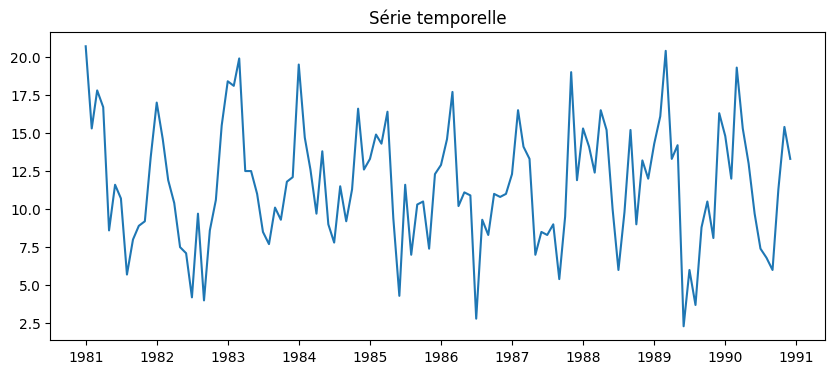

In [5]:
plt.figure(figsize=(10,4))
plt.plot(df['ds'], df['y'])
plt.title("Série temporelle")
plt.show()

## **6. Installation des Modeles et initialisation de Statsforecast**

In [ ]:
models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq='MS',
    n_jobs=-1
)

## **7. Prévision avec méthode de prévision**

In [7]:
fcst = sf.forecast(df = df,h=12)
fcst.head()

,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,14.457934,15.808121
1,Serie_1,1991-02-01,15.241832,15.108812
2,Serie_1,1991-03-01,15.029952,16.028211
3,Serie_1,1991-04-01,14.013956,13.414013
4,Serie_1,1991-05-01,12.090756,11.605935


## **8. Prévision avec ajustement et prédiction**

In [8]:
#===========================
# Enregistrement les modeles
#===========================
sf.fit(df=df)

StatsForecast(models=[AutoARIMA,AutoETS])

In [9]:
#======================================================================================
#Prédire ou prévoir les étapes « horizon » à venir à l'aide de la méthode de prédiction
#======================================================================================
predict = sf.predict(h=12)
predict.head()

,unique_id,ds,AutoARIMA,AutoETS
0,Serie_1,1991-01-01,14.457934,15.808121
1,Serie_1,1991-02-01,15.241832,15.108812
2,Serie_1,1991-03-01,15.029952,16.028211
3,Serie_1,1991-04-01,14.013956,13.414013
4,Serie_1,1991-05-01,12.090756,11.605935


## **9. Visualisation réel vs prévision**

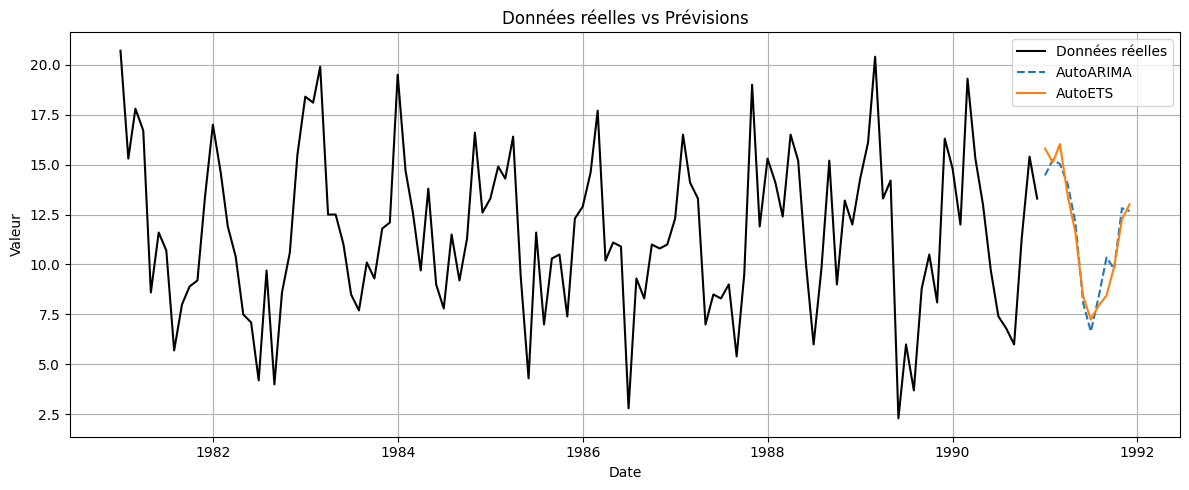

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Données réelles', color='black')
plt.plot(
    predict['ds'],
    predict['AutoARIMA'],
    label='AutoARIMA',
    linestyle='--'
)
plt.plot(predict['ds'],predict['AutoETS'],label='AutoETS')
plt.title('Données réelles vs Prévisions')
plt.xlabel('Date')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()